#  MODELIZACIÓN PARA CLASIFICACIÓN

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import classification_report

#from sklearn.metrics import plot_precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
import scikitplot as skplt
#from yellowbrick.classifier import discrimination_threshold

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
ruta_proyecto = 'C:/Users/Lenovo/Documents/portafolio_ds/automation/LEAD_KAGGLE'

Nombres de los archivos de datos.

In [3]:
nombre_x = 'x_preseleccionado.pickle'
nombre_y = 'y_preseleccionado.pickle'

Cargar los datos.

In [4]:
x = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_x)
y = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_y)

## MODELIZAR

### Reservar el dataset de validacion

In [5]:
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [6]:
pipe = Pipeline([('algoritmo',RandomForestClassifier())])

grid = [{'algoritmo': [LogisticRegression()],
         'algoritmo__n_jobs': [-1],
         'algoritmo__solver': ['saga'],
         'algoritmo__penalty': ['elasticnet', 'l1', 'l2', 'none'],
         'algoritmo__C': [0,0.25,0.5,0.75,1]}
       ]

### Optimizar los hiper parámetros

####  Con grid search

In [7]:
grid_search = GridSearchCV(estimator= pipe, 
                            param_grid = grid, 
                            cv = 3, 
                            scoring = 'roc_auc',
                            verbose = 0,
                            n_jobs = -1)

modelo = grid_search.fit(train_x,train_y)

pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__n_jobs,param_algoritmo__penalty,param_algoritmo__solver,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
17,0.15,0.04,0.03,0.02,LogisticRegression(),1.00,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.96,0.96,0.00,1
13,0.15,0.03,0.02,0.00,LogisticRegression(),0.75,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.96,0.96,0.00,2
9,0.14,0.02,0.03,0.00,LogisticRegression(),0.50,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.96,0.96,0.00,3
18,0.15,0.01,0.02,0.00,LogisticRegression(),1.00,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.96,0.96,0.00,4
14,0.15,0.00,0.02,0.00,LogisticRegression(),0.75,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.96,0.96,0.00,5
10,0.13,0.01,0.02,0.00,LogisticRegression(),0.50,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.95,0.96,0.00,6
5,0.20,0.02,0.03,0.00,LogisticRegression(),0.25,-1,l1,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.95,0.95,0.00,7
6,0.20,0.03,0.04,0.02,LogisticRegression(),0.25,-1,l2,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",0.96,0.95,0.95,0.95,0.00,8
16,0.01,0.00,0.00,0.00,LogisticRegression(),1.00,-1,elasticnet,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",NaN,NaN,NaN,NaN,NaN,9
15,0.01,0.00,0.00,0.00,LogisticRegression(),0.75,-1,none,saga,"{'algoritmo': LogisticRegression(), 'algoritmo...",NaN,NaN,NaN,NaN,NaN,9


## EVALUAR

### Predecir sobre validación

In [8]:
pred = modelo.best_estimator_.predict_proba(val_x)[:, 1]

### Evaluar sobre validación

In [9]:
roc_auc_score(val_y, pred)

0.9595123220834109

### Examinar el mejor modelo

In [10]:
modelo.best_estimator_

Pipeline(steps=[('algoritmo',
                 LogisticRegression(C=1, n_jobs=-1, penalty='l1',
                                    solver='saga'))])

In [11]:
modelo.best_estimator_.named_steps.algoritmo.coef_

array([[ 4.32127738,  4.13938085,  6.26386759,  4.40723695, -2.97744361,
         2.44600528, -2.8382707 ,  2.93120044, -3.12444831,  0.36474887,
         0.49915087]])

In [12]:
modelo.best_estimator_.named_steps.algoritmo.feature_names_in_

array(['tags_Will revert after reading the email',
       'total_time_spent_on_website_mms', 'tags_Closed by Horizzon',
       'asymmetrique_activity_score_mms', 'tags_Ringing',
       'last_notable_activity_SMS Sent', 'page_views_per_visit_mms',
       'lead_origin_Lead Add Form', 'tags_Already a student',
       'total_visits_mms', 'tags_OTHER'], dtype=object)

In [13]:
pd.DataFrame(data = modelo.best_estimator_.named_steps.algoritmo.coef_,
             columns =modelo.best_estimator_.named_steps.algoritmo.feature_names_in_).unstack().sort_values(ascending = False)

tags_Closed by Horizzon                   0    6.26
asymmetrique_activity_score_mms           0    4.41
tags_Will revert after reading the email  0    4.32
total_time_spent_on_website_mms           0    4.14
lead_origin_Lead Add Form                 0    2.93
last_notable_activity_SMS Sent            0    2.45
tags_OTHER                                0    0.50
total_visits_mms                          0    0.36
page_views_per_visit_mms                  0   -2.84
tags_Ringing                              0   -2.98
tags_Already a student                    0   -3.12
dtype: float64

## REPORTING DEL MODELO

### Gain Chart

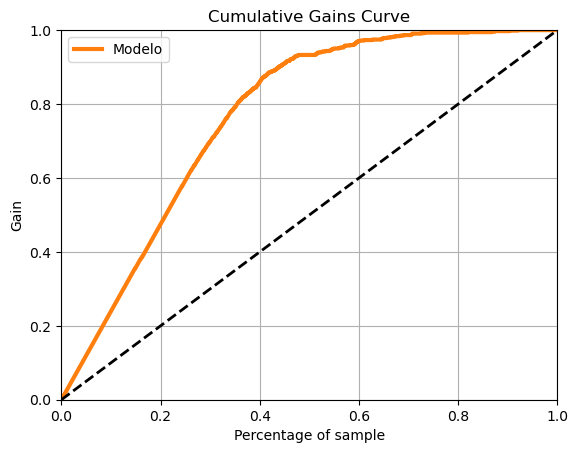

In [14]:
fig, ax = plt.subplots()

skplt.metrics.plot_cumulative_gain(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la línea de los ceros, que internamente tiene etiqueta 'Class 0'
lines = ax.get_lines()
# Buscar por la etiqueta y eliminar la línea correspondiente
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda sin incluir la línea de los ceros
plt.legend(labels=['Modelo'])

# Ahora puedes mostrar el gráfico
plt.show()

### Lift Chart

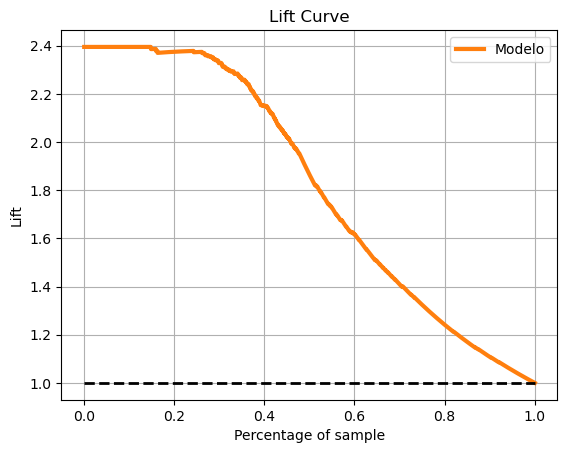

In [15]:
fig, ax = plt.subplots()

skplt.metrics.plot_lift_curve(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la línea de los ceros, que internamente tiene etiqueta 'Class 0'
lines = ax.get_lines()
# Buscar por la etiqueta y eliminar la línea correspondiente
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda sin incluir la línea de los ceros
plt.legend(labels=['Modelo'])

# Ahora puedes mostrar el gráfico
plt.show()

### ROC Chart

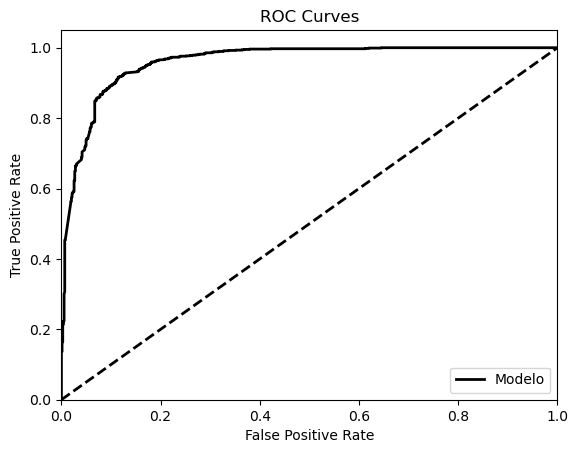

In [16]:
fig, ax = plt.subplots()

# Generamos la gráfica ROC
skplt.metrics.plot_roc(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax)

# Obtenemos todas las líneas y las leyendas
lines = ax.get_lines()

# Recorremos las líneas para eliminar las no deseadas, excepto la línea de la clase 0
for line in lines:
    if 'ROC curve of class 0' in line.get_label():
        line.set_label('Modelo')
    elif line.get_linestyle() != '--':  # Mantenemos la línea punteada pero sin leyenda
        line.set_visible(False)

# Solo añadimos al leyenda la línea de la clase 0 renombrada a 'Modelo'
handles, labels = ax.get_legend_handles_labels()
new_handles = [h for h, l in zip(handles, labels) if l == 'Modelo']
new_labels = ['Modelo']

ax.legend(new_handles, new_labels, loc='best')

# Ahora puedes mostrar el gráfico
plt.show();
